## 1. Mengimpor Library yang Diperlukan

In [7]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Rescaling
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint

print("TensorFlow Version:", tf.__version__)
print("GPU Tersedia:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Tersedia: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Eksplorasi Data & Resolusi Gambar

In [8]:
import kagglehub
path = kagglehub.dataset_download("muratkokludataset/rice-image-dataset")

Using Colab cache for faster access to the 'rice-image-dataset' dataset.


In [9]:
def print_images_resolution(directory):
    unique_sizes = set()
    total_images = 0

    if not os.path.exists(directory):
        print(f"Direktori {directory} tidak ditemukan.")
        return

    for subdir in os.listdir(directory):
        subdir_path = os.path.join(directory, subdir)
        if os.path.isdir(subdir_path) and not subdir.startswith('.'):
            image_files = [f for f in os.listdir(subdir_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
            num_images = len(image_files)
            print(f"{subdir}: {num_images} gambar")
            total_images += num_images

            # Mengambil sampel resolusi untuk efisiensi
            for img_file in image_files[:10]:
                img_path = os.path.join(subdir_path, img_file)
                with Image.open(img_path) as img:
                    unique_sizes.add(img.size)

    print("---- Sampel Resolusi Unik ----")
    for size in unique_sizes:
        print(f"- {size}")
    print("------------------------------")
    print(f"Total Keseluruhan Gambar: {total_images}")

# Jalankan fungsi eksplorasi
dataset_path = path + "/Rice_Image_Dataset"
print_images_resolution(dataset_path)

Karacadag: 15000 gambar
Basmati: 15000 gambar
Jasmine: 15000 gambar
Arborio: 15000 gambar
Ipsala: 15000 gambar
---- Sampel Resolusi Unik ----
- (250, 250)
------------------------------
Total Keseluruhan Gambar: 75000


## 3. Pembagian Dataset (Train, Validation, Test Set) & Data Augmentation

In [10]:
IMAGE_SIZE = (150, 150)
BATCH_SIZE = 32

# Memuat Training Set (80%)
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

# Memuat Data Sisa untuk Validasi dan Test (20%)
val_test_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

# Membagi Sisa Data menjadi 50% Validation dan 50% Test
val_test_batches = tf.data.experimental.cardinality(val_test_ds)
val_batches = val_test_batches // 2

val_ds = val_test_ds.take(val_batches)
test_ds = val_test_ds.skip(val_batches)

class_names = train_ds.class_names
print(f"Kelas yang ditemukan: {class_names}")
print(f"Jumlah batch training: {tf.data.experimental.cardinality(train_ds)}")
print(f"Jumlah batch validasi: {tf.data.experimental.cardinality(val_ds)}")
print(f"Jumlah batch testing: {tf.data.experimental.cardinality(test_ds)}")

Found 75000 files belonging to 5 classes.
Using 60000 files for training.
Found 75000 files belonging to 5 classes.
Using 15000 files for validation.
Kelas yang ditemukan: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']
Jumlah batch training: 1875
Jumlah batch validasi: 234
Jumlah batch testing: 235


In [11]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.1),
])

# Mengaplikasikan augmentasi hanya pada training dataset
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

# Mengoptimalkan performa input data pipeline menggunakan prefetch
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

## 4. Membangun Arsitektur Model Sequential CNN

In [12]:
model = Sequential([
    # Tahap Rescaling untuk mengubah nilai pixel menjadi rentang [0, 1]
    Rescaling(1./255, input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)),

    # Blok Konvolusi 1
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    # Blok Konvolusi 2
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    # Blok Konvolusi 3
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    # Blok Konvolusi 4
    Conv2D(256, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    # Flattening
    Flatten(),

    # Dense Layer Berderet dengan Regularisasi Dropout
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.3),

    # Output Layer dengan jumlah unit sesuai jumlah kelas (5)
    Dense(len(class_names), activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     6,423,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,944,069 (26.49 MB)

 Trainable params: 6,944,069 (26.49 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Kompilasi Model

In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 6 Implementasi Callback

In [14]:
class TargetAccuracyCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        acc = logs.get('accuracy', 0)
        val_acc = logs.get('val_accuracy', 0)
        if acc >= 0.96 and val_acc >= 0.96:
            print(f"\nEpoch {epoch+1}: Akurasi training ({acc*100:.2f}%) dan validasi ({val_acc*100:.2f}%) telah mencapai target minimal 96%. Pelatihan dihentikan.")
            self.model.stop_training = True

callbacks_list = [
    TargetAccuracyCallback(),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint(filepath='best_model.h5', monitor='val_accuracy', save_best_only=True)
]

## 7. Pelatihan Model (Training)

In [15]:
EPOCHS = 30

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_list,
    verbose=1
)

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.8136 - loss: 0.4609

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 405s 212ms/step - accuracy: 0.8967 - loss: 0.2722 - val_accuracy: 0.9674 - val_loss: 0.0973
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.9651 - loss: 0.1062
Epoch 2: Akurasi training (97.33%) dan validasi (96.74%) telah mencapai target minimal 96%. Pelatihan dihentikan.
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 362s 193ms/step - accuracy: 0.9733 - loss: 0.0819 - val_accuracy: 0.9674 - val_loss: 0.0874


## 8. Evaluasi Model pada Test Set

In [16]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Akurasi pada Test Set: {test_accuracy * 100:.2f}%")
print(f"Loss pada Test Set: {test_loss:.4f}")

235/235 ━━━━━━━━━━━━━━━━━━━━ 20s 66ms/step - accuracy: 0.9606 - loss: 0.1064
Akurasi pada Test Set: 96.06%
Loss pada Test Set: 0.1064


## 9. Membuat Plot Akurasi dan Loss Model

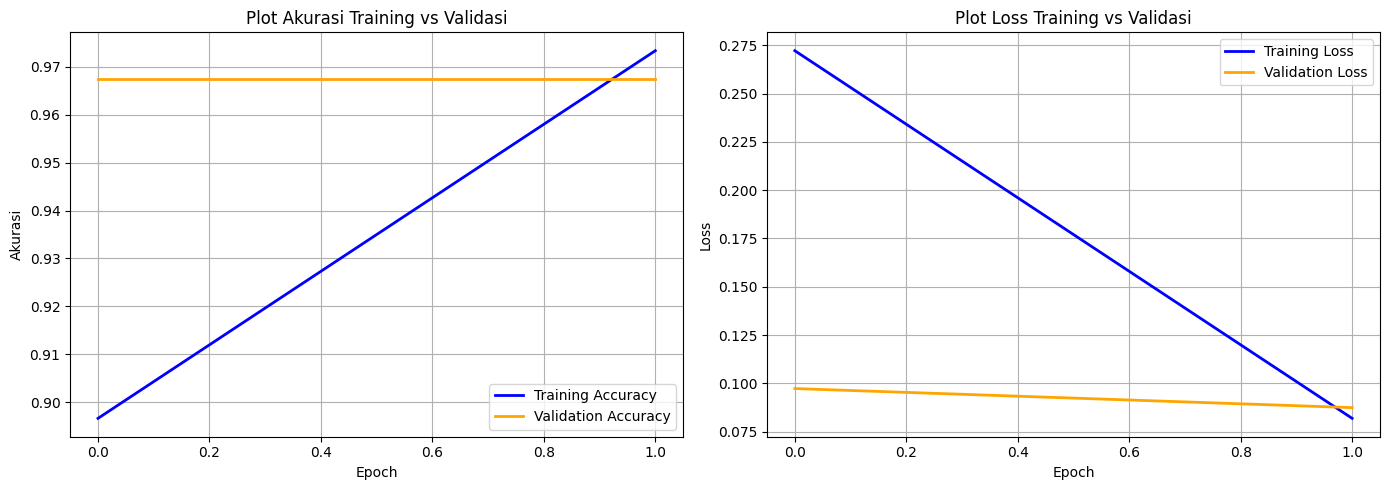

In [17]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Plot Akurasi Training vs Validasi')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend(loc='lower right')
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', linewidth=2)
plt.title('Plot Loss Training vs Validasi')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

## 10. Menyimpan Model ke Berbagai Format (SavedModel, TF-Lite, TFJS)

In [ ]:
# Pembuatan struktur direktori sesuai ketentuan
os.makedirs('submission/saved_model', exist_ok=True)
os.makedirs('submission/tflite', exist_ok=True)
os.makedirs('submission/tfjs_model', exist_ok=True)

# 1. Menyimpan ke format SavedModel (Menggunakan model.export untuk versi Keras terbaru)
model.export('submission/saved_model')
print("Model berhasil disimpan dalam format SavedModel.")

# 2. Mengonversi dan menyimpan ke format TF-Lite
converter = tf.lite.TFLiteConverter.from_saved_model('submission/saved_model')
tflite_model = converter.convert()

with open('submission/tflite/model.tflite', 'wb') as f:
    f.write(tflite_model)
print("Model berhasil dikonversi dan disimpan dalam format TF-Lite.")

# Menyimpan berkas label.txt untuk TF-Lite
with open('submission/tflite/label.txt', 'w') as f:
    for class_name in class_names:
        f.write(f"{class_name}\n")
print("Berkas label.txt berhasil dibuat.")

# 3. Mengonversi ke format TFJS
print("!tensorflowjs_converter --input_format=tf_saved_model --output_format=tfjs_graph_model submission/saved_model submission/tfjs_model")

Saved artifact at 'submission/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor_4')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  136752553699152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136752553700304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136752553700880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136752553701456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136752553694544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136752553702416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136752553703376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136752553702608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136752553703760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136752553703568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136752

## 11. Tahap Inferensi / Prediksi Menggunakan Model

In [19]:
def predict_rice_image(image_path, model, class_names):
    if not os.path.exists(image_path):
        print(f"File gambar {image_path} tidak ditemukan untuk inferensi.")
        return

    img = tf.keras.utils.load_img(image_path, target_size=IMAGE_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # Membuat batch

    predictions = model.predict(img_array)
    score = tf.nn.softmax(predictions[0])
    predicted_class = class_names[np.argmax(score)]
    confidence = 100 * np.max(score)

    plt.imshow(img)
    plt.title(f"Prediksi: {predicted_class} ({confidence:.2f}% Confidence)")
    plt.axis('off')
    plt.show()

    print(f"Gambar teridentifikasi sebagai varietas: {predicted_class} dengan tingkat keyakinan {confidence:.2f}%")

# sample_img_path = 'jasmine-rice.jpg'
# predict_rice_image(sample_img_path, model, class_names)